# Phase 3 — Information-Theoretic Analysis

Mutual Information (KSG), KL Divergence, and Surprisal evaluation
for both Kalman and Particle filters across the SNR sweep.

In [2]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt
from audio_io import (
    load_mono_16k, loop_to_length, mix_at_snr,
    peak_normalize, TARGET_SR
)
from kalman import fit_ar_per_frame, kalman_filter_signal, estimate_R
from particle import particle_filter_signal, estimate_t_params

OUT_DIR = pathlib.Path.cwd().parent / 'data' / 'synth'

## 1. Load pre-computed MI and KL results

In [3]:
LOG2E = np.log2(np.e)
with open(OUT_DIR / 'info_theory_results.json') as f:
    results = json.load(f)
for r in results:
    for k in ('mi_noisy','mi_kf','mi_pf','kl_noisy','kl_kf','kl_pf'): r[k] *= LOG2E

for r in results:
    print(f"SNR={r['snr_in']:+3d} | MI: noisy={r['mi_noisy']:.4f} KF={r['mi_kf']:.4f} PF={r['mi_pf']:.4f} "
          f"| KL: noisy={r['kl_noisy']:.4f} KF={r['kl_kf']:.4f} PF={r['kl_pf']:.4f}")

SNR= -5 | MI: noisy=1.1040 KF=2.2021 PF=1.8452 | KL: noisy=2.4631 KF=0.7932 PF=0.7903
SNR= +0 | MI: noisy=1.6854 KF=2.6322 PF=2.2308 | KL: noisy=1.7447 KF=0.6665 PF=0.7156
SNR= +5 | MI: noisy=2.4276 KF=3.2390 PF=2.7629 | KL: noisy=1.1445 KF=0.5468 PF=0.6273
SNR=+10 | MI: noisy=3.3101 KF=3.9347 PF=3.4027 | KL: noisy=0.7029 KF=0.4449 PF=0.5270
SNR=+15 | MI: noisy=4.1990 KF=4.6439 PF=4.1225 | KL: noisy=0.3973 KF=0.3475 PF=0.4348


## 2. MI vs SNR (the central plot)

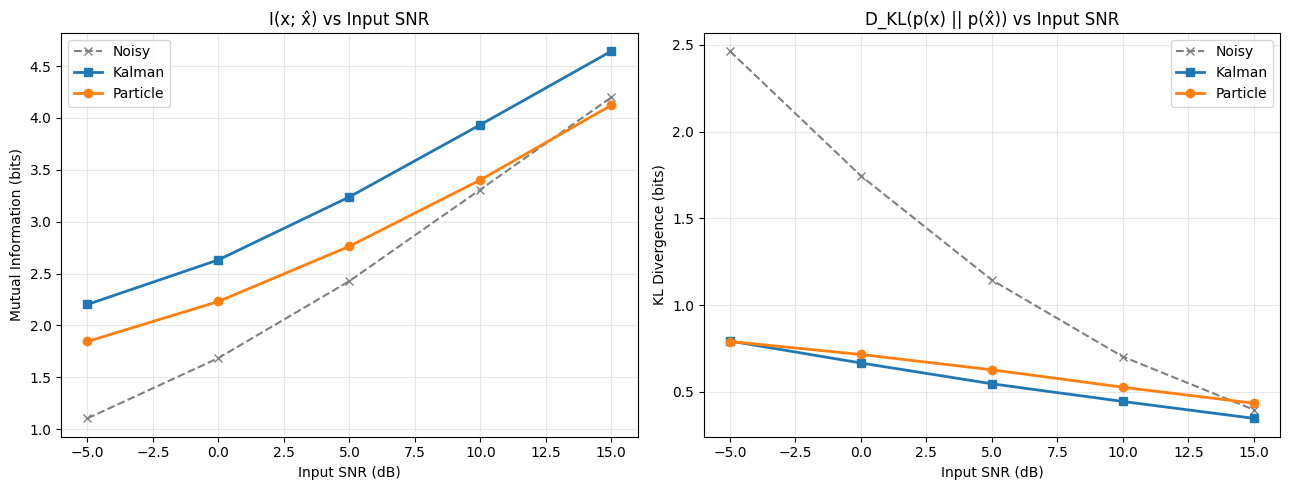

In [4]:
snrs = [r['snr_in'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(snrs, [r['mi_noisy'] for r in results], 'x--', label='Noisy', color='gray')
ax1.plot(snrs, [r['mi_kf'] for r in results], 's-', label='Kalman', linewidth=2)
ax1.plot(snrs, [r['mi_pf'] for r in results], 'o-', label='Particle', linewidth=2)
ax1.set_xlabel('Input SNR (dB)')
ax1.set_ylabel('Mutual Information (bits)')
ax1.set_title('I(x; x̂) vs Input SNR')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(snrs, [r['kl_noisy'] for r in results], 'x--', label='Noisy', color='gray')
ax2.plot(snrs, [r['kl_kf'] for r in results], 's-', label='Kalman', linewidth=2)
ax2.plot(snrs, [r['kl_pf'] for r in results], 'o-', label='Particle', linewidth=2)
ax2.set_xlabel('Input SNR (dB)')
ax2.set_ylabel('KL Divergence (bits)')
ax2.set_title('D_KL(p(x) || p(x̂)) vs Input SNR')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'mi_kl_vs_snr.png'), dpi=150)
plt.show()